In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score,confusion_matrix,roc_curve,auc


In [2]:
## Create a classification DataSet
np.random.seed()
cl0= np.random.normal(loc=5,scale=2,size=200) 
cl1= np.random.normal(loc=10,scale=2,size=200)
toy_df = pd.DataFrame({'X':cl0,'Y':5})
toy_df = pd.concat([toy_df,pd.DataFrame({'X':cl1,'Y':10})])

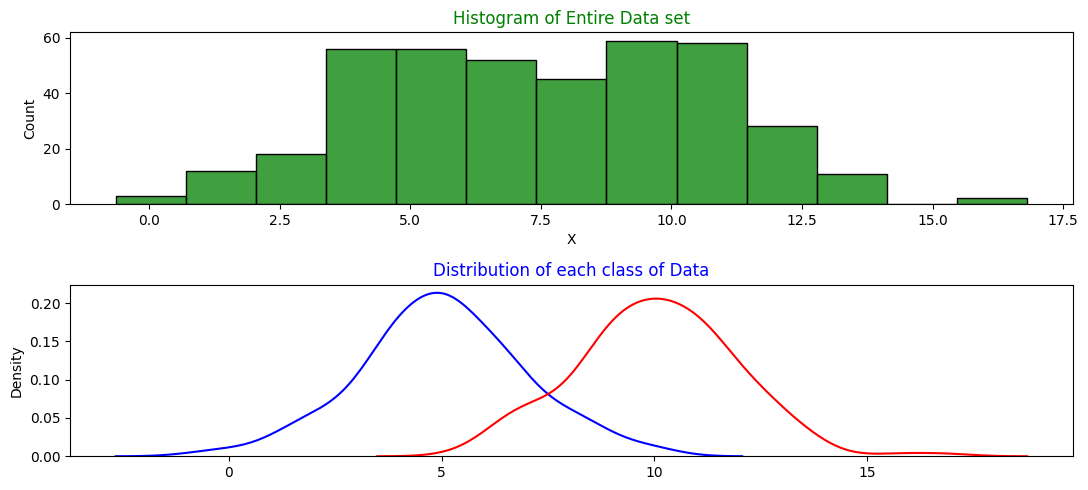

In [3]:
## Visually Inspect the Data set
f,ax = plt.subplots(2,1,figsize=(11,5))
sns.histplot(toy_df['X'],ax=ax[0],color='green')
ax[0].set_title('Histogram of Entire Data set',color = 'green')
sns.kdeplot(cl0,ax=ax[1],color='blue')
sns.kdeplot(cl1,ax=ax[1],color = 'red')
ax[1].set_title('Distribution of each class of Data',color = 'Blue')
plt.tight_layout()
plt.show()
plt.close()

In [4]:
x_vals = toy_df[['X']] ## Pay attention to double bracket '[[]]'. This is needed as we are using X as single dimension data
y_vals = toy_df['Y']
Xtrain,Xtest,Ytrain,Ytest = train_test_split(x_vals,y_vals,random_state = 49, test_size=0.2)
display(toy_df)
#display(Ytrain)

<IPython.core.display.Javascript object>

,X,Y
0,6.030769,5
1,5.687656,5
2,1.664387,5
3,3.412365,5
4,5.689978,5
...,...,...
195,9.013163,10
196,9.199180,10
197,8.797091,10
198,11.813661,10


In [5]:
## Calculate Logistic Regresssion co-efficients
lgstcls = LogisticRegression(max_iter=77)

## Fit the model with Training Data
lgstcls.fit(Xtrain,Ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
## Predict Probabilities of Train using Estimated Params
PY_train = lgstcls.predict_proba(Xtrain)
## Predict Probabilities of Test using Estimated Param
PY_test = lgstcls.predict_proba(Xtest)

In [7]:
lgstcls.classes_

array([ 5, 10])

In [8]:
## Now create Train & Test Dataframes with various Threshold values, P(Y=1)
thlds = np.linspace(0.1,1,num=5)
test_df = pd.DataFrame()
train_df = pd.DataFrame()
thlds = np.linspace(0.1,1,num=5)
train_df['X']= Xtrain
train_df['Y'] = Ytrain
train_df['PY1'] = PY_train[:,1] ## This PY_train is from predict_proba() 
test_df['X']= Xtest
test_df['Y'] = Ytest
test_df['PY1'] = PY_test[:,1] ## This PY_test is from predict_proba() 

for th in thlds:
    Y_train_pred= [10 if p > th else 5 for p in PY_train[:,1]]
    Y_test_pred = [10 if p > th else 5 for p in PY_test[:,1]]

    train_df[f'Y_pred_th {th:0.2f}'] = Y_train_pred
    test_df[f'Y_pred_th {th:0.2f}'] = Y_test_pred


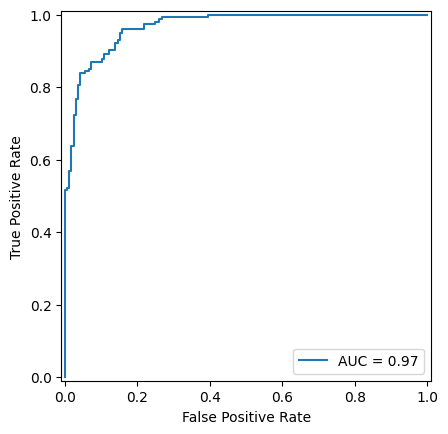

In [9]:
## Model Performance
## Use Y & P(Y=1) and plot ROC Curve for various Thld
fpr, tpr, thresholds = roc_curve(train_df['Y'],train_df['PY1'],pos_label=10)
display1 = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr))
display1.plot()
plt.show()

In [10]:
display(train_df)

,X,Y,PY1,Y_pred_th 0.10,Y_pred_th 0.33,Y_pred_th 0.55,Y_pred_th 0.78,Y_pred_th 1.00
99,8.262635,10,0.683354,10,10,10,5,5
192,6.924409,5,0.280091,10,5,5,5,5
1,5.687656,5,0.073964,5,5,5,5,5
118,10.851101,10,0.983424,10,10,10,10,5
93,9.301275,10,0.890799,10,10,10,10,5
...,...,...,...,...,...,...,...,...
189,7.515573,10,0.453340,10,10,5,5,5
170,10.061913,10,0.955753,10,10,10,10,5
44,13.898250,10,0.999659,10,10,10,10,5
182,1.720772,5,0.000497,5,5,5,5,5


In [11]:
display(test_df)

,X,Y,PY1,Y_pred_th 0.10,Y_pred_th 0.33,Y_pred_th 0.55,Y_pred_th 0.78,Y_pred_th 1.00
117,3.399779,5,0.004251,5,5,5,5,5
102,9.850979,10,0.942820,10,10,10,10,5
32,11.323261,10,0.990875,10,10,10,10,5
149,3.746481,5,0.006610,5,5,5,5,5
2,12.999264,10,0.998924,10,10,10,10,5
...,...,...,...,...,...,...,...,...
34,11.191737,10,0.989219,10,10,10,10,5
178,4.618633,5,0.019919,5,5,5,5,5
18,5.265439,5,0.044452,5,5,5,5,5
134,6.874748,10,0.267452,10,5,5,5,5


In [12]:
# Get components of the confusion matrix
tn, fp, fn, tp = confusion_matrix(train_df['Y'],train_df['Y_pred_th 0.10']).ravel()

# Calculate rates
tpr = tp / (tp + fn)  # Same as recall_score
fpr = fp / (fp + tn)
c_accuracy  = accuracy_score(train_df['Y'],train_df['Y_pred_th 0.10'])
c_recall    = recall_score(train_df['Y'],train_df['Y_pred_th 0.10'],pos_label=10)
c_precision = precision_score(train_df['Y'],train_df['Y_pred_th 0.10'],pos_label=10)
c_f1score   = f1_score(train_df['Y'],train_df['Y_pred_th 0.10'],pos_label=10)


In [13]:
c_accuracy

0.840625

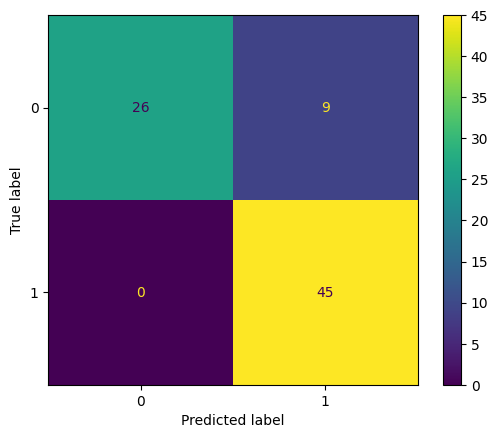

In [14]:
cm = confusion_matrix(test_df['Y'],test_df['Y_pred_th 0.10'])
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()
plt.close()


In [15]:
nm = [f'Y_pred_th {s:0.02f}' for s in thlds]
for i,col_n in enumerate(nm):
    print(col_n,i)

Y_pred_th 0.10 0
Y_pred_th 0.33 1
Y_pred_th 0.55 2
Y_pred_th 0.78 3
Y_pred_th 1.00 4


In [16]:
len(thlds)

5

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


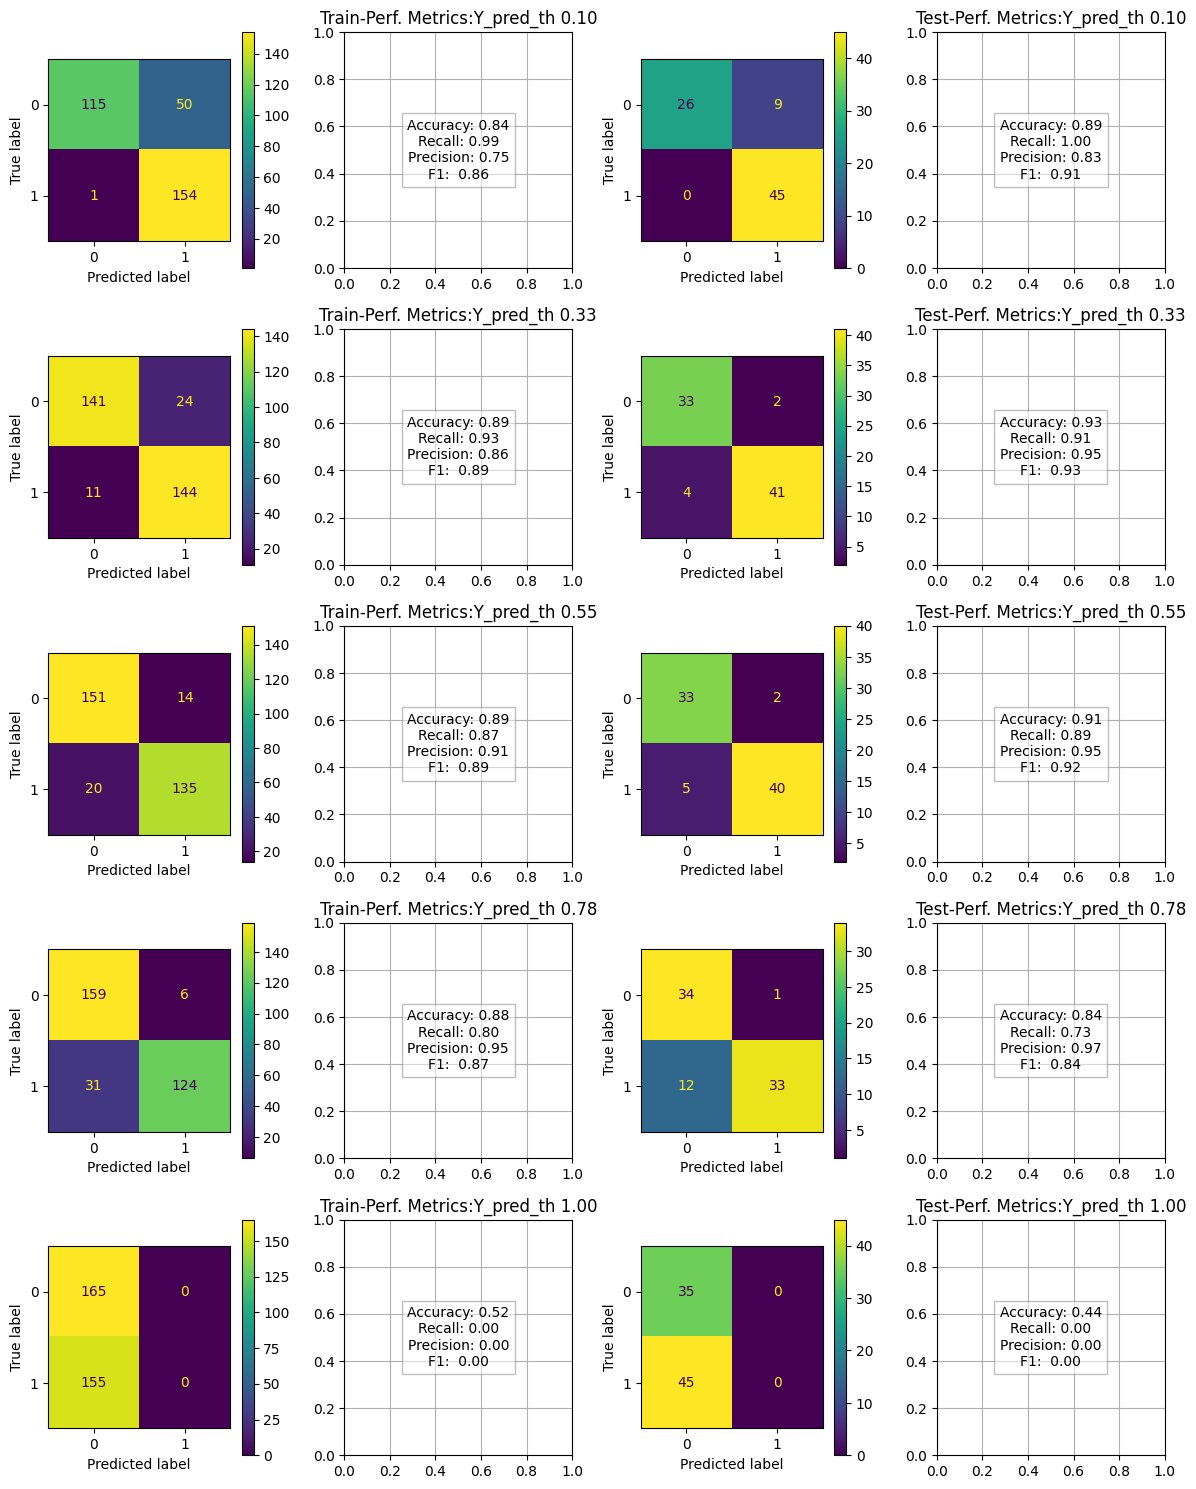

In [17]:
def print_text(Y_true,Y_pred,ax,Title,pos_class_label=10):
    c_accuracy  = accuracy_score(Y_true,Y_pred)
    c_recall    = recall_score(Y_true,Y_pred,pos_label=pos_class_label)
    c_precision = precision_score(Y_true,Y_pred,pos_label=pos_class_label)
    c_f1score   = f1_score(Y_true,Y_pred,pos_label=pos_class_label)
    stats_text = f"Accuracy: {c_accuracy:.2f}\nRecall: {c_recall:.2f}\nPrecision: {c_precision:.2f}\nF1:  {c_f1score:.2f}"
    #ax.set_title('Performance Metrix')
    ax.grid('off')
    ax.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
    ax.set_title(Title)
    


f,axes = plt.subplots(len(thlds),4,figsize=(12,len(thlds)*3))
for i, col_n in enumerate(nm):
    cm = confusion_matrix(train_df['Y'],train_df[col_n])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[i,0])

    print_text(train_df['Y'],train_df[col_n],ax=axes[i,1],Title=f'Train-Perf. Metrics:{nm[i]}')


    cm = confusion_matrix(test_df['Y'],test_df[col_n])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[i,2])

    print_text(test_df['Y'],test_df[col_n],ax=axes[i,3],Title=f'Test-Perf. Metrics:{nm[i]}')

plt.tight_layout()
plt.show()
plt.close()
